# Block 2, Assignment 2: Adsorption in IRMOF-1 with AiiDAlab

**Group C**

**Team members:** Pamela Sampaa Afaki, Sarhini Nour, Chiara Nicole Bifulco, Alice Bolard

This notebook follows the assignment questions. We used AiiDAlab to simulate adsorption of the pure gases and pyIAST to calculate adsorption of the mixture. The simulation results are stored in the `data` folder.


In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyiast

BLUE, RED, GREEN = "#0072B2", "#D55E00", "#009E73"

# Ideal gas constant in kJ/(mol.K)
R = 8.314e-3
# Molar volume of an ideal gas at STP (0 C, 1 atm), in cm3/mmol
V_STP = 22.414

# Composition of the biogas from the assignment sheet
y_CO2, y_CH4 = 0.4, 0.6
T = 300.0   # K


def read_aiidalab(path):
    # AiiDAlab exports its results as a two-column Key,Value CSV.
    # Returns the values as a Series and, if there is one, the isotherm as a DataFrame.
    res = pd.read_csv(path, index_col="Key")["Value"]
    if "isotherm" not in res:
        return res, None
    d = ast.literal_eval(res["isotherm"])     # the isotherm is stored as a dict in one cell
    iso = pd.DataFrame({"pressure_bar": d["pressure"],                      # bar
                        "loading_mmol_g": d["loading_absolute_average"],     # mol/kg = mmol/g
                        "loading_err_mmol_g": d["loading_absolute_dev"],
                        "dH_kJ_mol": d["enthalpy_of_adsorption_average"],
                        "dH_err_kJ_mol": d["enthalpy_of_adsorption_dev"]})
    return res, iso

---
# Simulations of the pure gases with AiiDAlab

## 1. The calculations AiiDAlab offers for adsorption studies

1. Pore analysis (Zeo++). This calculation examines the empty spaces inside the material. A spherical probe with a chosen radius represents the size of a particle that could enter the pores. Zeo++ determines which regions the probe can access and calculates properties such as density, accessible surface area (ASA), accessible probe-occupiable volume (POAV) and porosity. These properties describe the space available for adsorption, but do not directly tell us how strongly a particular gas is attracted to the material.

2. Henry coefficient (Widom insertions, RASPA). This method virtually inserts a single gas molecule at many random positions and orientations inside the material. At each insertion, it evaluates the molecule’s interaction energy with the surrounding atoms. The results are combined to calculate the Henry coefficient, which describes adsorption at very low pressure. A larger Henry coefficient means that more gas is adsorbed at the same sufficiently low pressure, indicating stronger affinity for the material. Widom insertion also estimates the adsorption enthalpy at infinite dilution, where interactions between adsorbed gas molecules are negligible.

3. Adsorption isotherm (GCMC, RASPA). This method calculates how much gas is adsorbed at a specified temperature and gas pressure. During the simulation, molecules are randomly inserted, removed, moved or rotated. These changes are accepted or rejected according to their energies and the imposed conditions. After an initial equilibration period, the simulation measures the average amount adsorbed. Repeating the calculation at several pressures produces an adsorption isotherm, showing how adsorption changes with pressure at a constant temperature. Unlike Widom insertion, GCMC accounts for interactions between multiple adsorbed molecules.

## 2. Pore analysis of IRMOF-1

We used the pore analysis app with a probe radius of 1.525 Å. Porosity is the fraction of the unit cell volume accessible to the probe:

$$\phi = \frac{\mathrm{POAV}}{V_{cell}}.$$


In [2]:
zeo, _ = read_aiidalab("data/IRMOF-1_pore_analysis.csv")

rho     = float(zeo["Density"])                        # g/cm3
ASA     = float(zeo["ASA_A^2"])                        # A^2 per unit cell
POAV    = float(zeo["POAV_A^3"])                       # A^3 per unit cell
phi_zeo = float(zeo["POAV_Volume_fraction"])           # porosity as reported by Zeo++
V_cell  = float(zeo["Unitcell_volume"])                # A^3
LCD     = float(zeo["Largest_included_sphere"])        # largest cavity, A
PLD     = float(zeo["Largest_free_sphere"])            # pore limiting diameter, A

# Cross-checks: porosity from POAV / V_cell, and the ASA per gram
# mass of the cell (g) = rho (g/cm3) * V_cell (A^3) * 1e-24 (cm3/A^3)
m_cell = rho * V_cell * 1e-24
phi = POAV / V_cell
ASA_m2_g = ASA * 1e-20 / m_cell          # 1 A^2 = 1e-20 m^2
POAV_cm3_g = POAV * 1e-24 / m_cell

print(f"Density            : {rho:.4f} g/cm3")
print(f"ASA                : {ASA:.1f} A^2   = {ASA_m2_g:.0f} m^2/g")
print(f"POAV               : {POAV:.1f} A^3   = {POAV_cm3_g:.3f} cm3/g")
print(f"Porosity           : {phi:.4f}   (Zeo++ reports {phi_zeo:.4f})")
print(f"Largest cavity     : {LCD:.2f} A,  pore limiting diameter {PLD:.2f} A")

Density            : 0.5770 g/cm3
ASA                : 3964.7 A^2   = 3876 m^2/g
POAV               : 13737.4 A^3   = 1.343 cm3/g
Porosity           : 0.7750   (Zeo++ reports 0.7750)
Largest cavity     : 15.00 A,  pore limiting diameter 8.03 A


**Results for question 2:**

| Property | Value | Unit | Meaning |
|:---|:---|:---|:---|
| Density | 0.577 | g·cm⁻³ | Mass of the crystal per unit volume, including its pores. |
| Accessible surface area (ASA) | 3965 | Å² per unit cell | Surface area that the probe can reach. |
| ASA per gram | 3876 | m²·g⁻¹ | Accessible surface area per gram of material. |
| Probe-occupiable accessible volume (POAV) | 13737 | Å³ per unit cell | Accessible pore volume that the probe can occupy. |
| POAV per gram | 1.343 | cm³·g⁻¹ | Accessible pore volume per gram of material. |
| Porosity | 0.775 | Dimensionless | Fraction of the unit cell volume occupied by accessible pores. |

IRMOF-1 has a low density and an accessible pore volume of about 78% of the crystal volume. The pore analysis found no inaccessible pockets. Its narrowest pore opening is about 8.0 Å, larger than the molecular diameters of CO₂ (3.3 Å) and CH₄ (3.8 Å). Both gases can therefore enter the pores. Any preference for one gas is mainly due to its interactions with the framework rather than exclusion based on size.


## 3. Henry coefficients of CO₂ and CH₄ at 300 K

The isotherm workflow calculated the Henry coefficients using 50,000 Widom cycles. It also gave the adsorption energy, which we used to calculate the adsorption enthalpy at very low loading:

$$\Delta H = \langle\Delta U\rangle - RT.$$

At sufficiently low pressure, the amount adsorbed follows Henry's law, $q=K_H P$. The ratio of the two Henry coefficients therefore gives the low-pressure selectivity:

$$S^0 = \frac{K_{H,CO_2}}{K_{H,CH_4}}.$$


In [3]:
res, iso = {}, {}
for gas in ["CO2", "CH4"]:
    res[gas], iso[gas] = read_aiidalab(f"data/IRMOF-1_{gas}_300K.csv")

KH_CO2, dKH_CO2 = float(res["CO2"]["henry_coefficient_average"]), float(res["CO2"]["henry_coefficient_dev"])
KH_CH4, dKH_CH4 = float(res["CH4"]["henry_coefficient_average"]), float(res["CH4"]["henry_coefficient_dev"])

# Widom adsorption energy, and the enthalpy at zero loading dH = <dU> - RT  (kJ/mol)
dU_CO2 = float(res["CO2"]["adsorption_energy_widom_average"])
dU_CH4 = float(res["CH4"]["adsorption_energy_widom_average"])
dH_CO2 = dU_CO2 - R * T
dH_CH4 = dU_CH4 - R * T

# mol/(kg.Pa) is the same as mmol/(g.Pa); multiply by 1e5 to get mmol/(g.bar)
KH_CO2_bar = KH_CO2 * 1e5
KH_CH4_bar = KH_CH4 * 1e5
S0 = KH_CO2 / KH_CH4
# error on the ratio from the relative errors of the two KH
dS0 = S0 * np.sqrt((dKH_CO2 / KH_CO2)**2 + (dKH_CH4 / KH_CH4)**2)

print(f"{'gas':>4} | {'K_H (mol/(kg.Pa))':>22} | {'K_H (mmol/(g.bar))':>18} | {'<dU> (kJ/mol)':>13} | {'dH (kJ/mol)':>11}")
print("-" * 83)
for gas, KH, dKH, dU, dH in [("CO2", KH_CO2, dKH_CO2, dU_CO2, dH_CO2), ("CH4", KH_CH4, dKH_CH4, dU_CH4, dH_CH4)]:
    print(f"{gas:>4} | {KH:>10.4e} +/- {dKH:.1e} | {KH * 1e5:>18.4f} | {dU:>13.2f} | {dH:>11.2f}")
print(f"\nLow-pressure selectivity K_H(CO2)/K_H(CH4) = {S0:.2f} +/- {dS0:.2f}")

 gas |      K_H (mol/(kg.Pa)) | K_H (mmol/(g.bar)) | <dU> (kJ/mol) | dH (kJ/mol)
-----------------------------------------------------------------------------------
 CO2 | 4.9557e-06 +/- 1.5e-08 |             0.4956 |         -9.18 |      -11.67
 CH4 | 1.1202e-06 +/- 8.4e-10 |             0.1120 |         -3.29 |       -5.78

Low-pressure selectivity K_H(CO2)/K_H(CH4) = 4.42 +/- 0.01


**Results for question 3:**

| Gas | $K_H$ (mol·kg⁻¹·Pa⁻¹) | $\Delta H$ (kJ·mol⁻¹) |
|:---:|:---:|:---:|
| CO₂ | $(4.956 \pm 0.015)\times10^{-6}$ | $-11.7$ |
| CH₄ | $(1.120 \pm 0.001)\times10^{-6}$ | $-5.8$ |

$$S^{0}_{CO_2/CH_4} = 4.42 \pm 0.01$$

The larger Henry coefficient shows that IRMOF-1 has a stronger affinity for CO₂ than for CH₄. At very low pressure, the selectivity is 4.42.

The more negative CO₂ adsorption enthalpy also indicates stronger interactions with the framework, consistent with its quadrupole interacting with framework charges. The relatively small adsorption enthalpies suggest that regeneration would require little energy. However, selectivity alone does not determine the methane purity achievable in a separation process.


## 4. Pure-component isotherms at 300 K

We calculated the pure-gas isotherms from 0.2 to 10.2 bar, with no more than 0.6 bar between pressure points. Each GCMC simulation used 500 initialisation cycles and 5,000 production cycles. The dashed lines show Henry's law, $q=K_H P$, using the coefficients from question 3.


In [4]:
for gas, df in iso.items():
    qsat_est = float(res[gas]["Estimated_saturation_loading"])
    print(f"{gas}: {len(df)} pressure points, from {df.pressure_bar.min():.1f} to "
          f"{df.pressure_bar.max():.1f} bar")
    print(f"     loading at {df.pressure_bar.iloc[-1]:.1f} bar = {df.loading_mmol_g.iloc[-1]:.2f} mmol/g, "
          f"which is {100 * df.loading_mmol_g.iloc[-1] / qsat_est:.0f} % of the saturation "
          f"loading estimated by AiiDAlab ({qsat_est:.1f} mmol/g)")
    print(f"     q/P goes from {(df.loading_mmol_g / df.pressure_bar).iloc[0]:.3f} to "
          f"{(df.loading_mmol_g / df.pressure_bar).iloc[-1]:.3f} mmol/(g.bar)\n")

iso_table = pd.DataFrame({"P (bar)": iso["CO2"].pressure_bar,
                          "q CO2 (mmol/g)": iso["CO2"].loading_mmol_g,
                          "q CH4 (mmol/g)": iso["CH4"].loading_mmol_g})
print(iso_table.round(3).to_string(index=False))

CO2: 18 pressure points, from 0.2 to 10.2 bar
     loading at 10.2 bar = 7.04 mmol/g, which is 26 % of the saturation loading estimated by AiiDAlab (26.8 mmol/g)
     q/P goes from 0.519 to 0.690 mmol/(g.bar)

CH4: 18 pressure points, from 0.2 to 10.2 bar
     loading at 10.2 bar = 1.12 mmol/g, which is 3 % of the saturation loading estimated by AiiDAlab (33.9 mmol/g)
     q/P goes from 0.110 to 0.110 mmol/(g.bar)

 P (bar)  q CO2 (mmol/g)  q CH4 (mmol/g)
     0.2           0.104           0.022
     0.8           0.391           0.090
     1.4           0.721           0.159
     2.0           1.054           0.224
     2.6           1.358           0.289
     3.2           1.704           0.361
     3.8           2.135           0.419
     4.4           2.463           0.486
     5.0           2.904           0.567
     5.6           3.115           0.611
     6.2           3.573           0.687
     6.8           4.072           0.757
     7.4           4.587           0.822
     8.

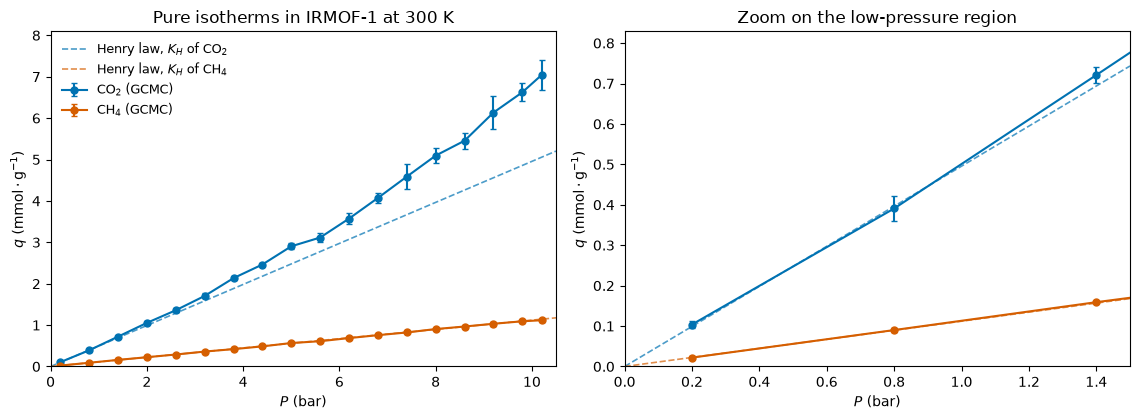

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))

for ax, P_max in [(ax1, 10.5), (ax2, 1.5)]:
    for gas, colour, KH in [("CO2", BLUE, KH_CO2_bar), ("CH4", RED, KH_CH4_bar)]:
        df = iso[gas]
        ax.errorbar(df.pressure_bar, df.loading_mmol_g, yerr=df.loading_err_mmol_g,
                    fmt="o-", color=colour, ms=5, lw=1.5, capsize=2,
                    label=f"{gas[:2]}$_{gas[2]}$ (GCMC)")
        P_line = np.linspace(0, P_max, 50)
        ax.plot(P_line, KH * P_line, ls="--", lw=1.2, color=colour, alpha=0.7,
                label=rf"Henry law, $K_H$ of {gas[:2]}$_{gas[2]}$")
    ax.set_xlim(0, P_max)
    ax.set_xlabel(r"$P\ (\mathrm{bar})$")
    ax.set_ylabel(r"$q\ (\mathrm{mmol \cdot g^{-1}})$")

ax1.set_ylim(0, 1.15 * max(df.loading_mmol_g.max() for df in iso.values()))
ax1.set_title("Pure isotherms in IRMOF-1 at 300 K")
ax2.set_ylim(0, 1.15 * max(df[df.pressure_bar <= 1.5].loading_mmol_g.max()
                            for df in iso.values()))
ax2.set_title("Zoom on the low-pressure region")
ax1.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

At 10.2 bar, IRMOF-1 adsorbs 7.04 mmol·g⁻¹ of CO₂ and 1.12 mmol·g⁻¹ of CH₄. Neither curve reaches a plateau. These amounts are about 26% and 3% of the saturation loadings estimated by AiiDAlab, respectively.

Both gases approximately follow Henry's law at low pressure. CH₄ remains nearly linear throughout the range, while CO₂ adsorption increases more rapidly at higher pressure. The CO₂ adsorption enthalpy also becomes more negative, from about −11.7 to −14.8 kJ·mol⁻¹. This is consistent with attractive interactions between adsorbed CO₂ molecules, which the Langmuir model neglects.


---
# The CO₂/CH₄ mixture with IAST

IAST uses the pure-gas isotherms to predict how much of each gas is adsorbed from a mixture. It assumes that the adsorbed gases form an ideal solution:

$$P y_i = P_i^0 x_i.$$

Here, $P$ is the total gas pressure, $y_i$ is the mole fraction in the gas and $x_i$ is the mole fraction in the adsorbed phase. The reference pressure $P_i^0$ is the pressure at which the pure gas has the same spreading pressure as the mixture. It is found from the pure-gas isotherm:

$$\frac{\pi A}{RT} = \int_0^{P_i^0} \frac{q_i^0(P)}{P}\,dP.$$

Spreading pressure describes the change in surface free energy caused by adsorption. In this expression, $A$ is the surface area per unit mass and $q_i^0$ is the amount of pure gas adsorbed per unit mass.


## 5. Binary isotherms with the linear interpolation method

We used `InterpolatorIsotherm` to connect the pure-gas GCMC points with straight lines. It includes the point $(0,0)$ to describe adsorption below the first measured pressure. The gas mixture contains 40% CO₂ and 60% CH₄.

We calculated the mixture isotherms from 0.1 to 3.9 bar in steps of 0.2 bar, then added 4.0 bar. We also checked that the reference pressures $P_i^0$ stayed below 10.2 bar, so the calculation did not require high-pressure extrapolation.


In [6]:
# Interpolator isotherms built directly from the GCMC data
iso_CO2 = pyiast.InterpolatorIsotherm(iso["CO2"], loading_key="loading_mmol_g",
                                      pressure_key="pressure_bar",
                                      fill_value=iso["CO2"].loading_mmol_g.max())
iso_CH4 = pyiast.InterpolatorIsotherm(iso["CH4"], loading_key="loading_mmol_g",
                                      pressure_key="pressure_bar",
                                      fill_value=iso["CH4"].loading_mmol_g.max())


def binary_iast(P_tot, yCO2):
    # Returns (q_CO2, q_CH4) in mmol/g and the two pure-component pressures P0 in bar
    yCH4 = 1 - yCO2
    q = pyiast.iast(np.array([P_tot * yCO2, P_tot * yCH4]), [iso_CO2, iso_CH4],
                    warningoff=True)
    x = q / q.sum()                                   # adsorbed-phase mole fractions
    P0 = P_tot * np.array([yCO2, yCH4]) / x           # from  P y_i = P0_i x_i
    return q, P0


P_grid = np.append(np.arange(0.1, 4.0, 0.2), 4.0)     # bar
results = [binary_iast(P, y_CO2) for P in P_grid]
q_mix = np.array([r[0] for r in results])            # columns: CO2, CH4
P0_mix = np.array([r[1] for r in results])

mix = pd.DataFrame({"P_tot (bar)": P_grid,
                    "q_CO2 (mmol/g)": q_mix[:, 0],
                    "q_CH4 (mmol/g)": q_mix[:, 1]})
print(mix.round(4).to_string(index=False))
print(f"\nLargest P0 reached: CO2 {P0_mix[:, 0].max():.2f} bar, CH4 {P0_mix[:, 1].max():.2f} bar"
      f"  (data go up to {min(df.pressure_bar.max() for df in iso.values()):.1f} bar)")

 P_tot (bar)  q_CO2 (mmol/g)  q_CH4 (mmol/g)
         0.1          0.0208          0.0066
         0.3          0.0625          0.0201
         0.5          0.1026          0.0333
         0.7          0.1411          0.0463
         0.9          0.1795          0.0593
         1.1          0.2178          0.0723
         1.3          0.2569          0.0856
         1.5          0.2946          0.0986
         1.7          0.3370          0.1128
         1.9          0.3807          0.1274
         2.1          0.4255          0.1424
         2.3          0.4650          0.1553
         2.5          0.5089          0.1695
         2.7          0.5532          0.1838
         2.9          0.5971          0.1980
         3.1          0.6409          0.2120
         3.3          0.6871          0.2270
         3.5          0.7299          0.2408
         3.7          0.7733          0.2547
         3.9          0.8145          0.2679
         4.0          0.8344          0.2742

Largest P

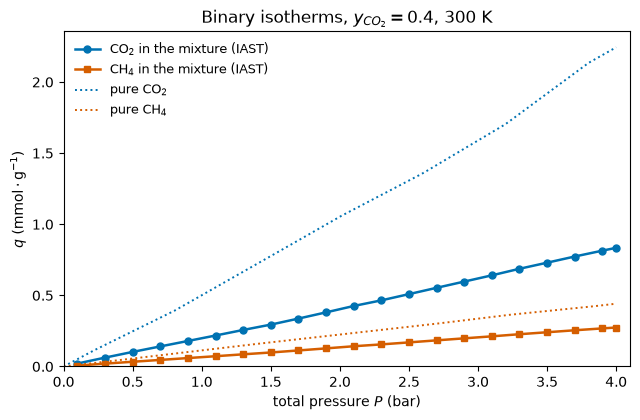

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.3))

ax.plot(P_grid, q_mix[:, 0], "o-", color=BLUE, ms=5, lw=1.8,
        label=r"CO$_2$ in the mixture (IAST)")
ax.plot(P_grid, q_mix[:, 1], "s-", color=RED, ms=5, lw=1.8,
        label=r"CH$_4$ in the mixture (IAST)")

# The pure isotherms, for comparison
P_pure = np.linspace(0, 4.0, 200)
ax.plot(P_pure, iso_CO2.loading(P_pure), ls=":", color=BLUE, lw=1.4,
        label=r"pure CO$_2$")
ax.plot(P_pure, iso_CH4.loading(P_pure), ls=":", color=RED, lw=1.4,
        label=r"pure CH$_4$")

ax.set_xlim(0, 4.1)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"total pressure $P\ (\mathrm{bar})$")
ax.set_ylabel(r"$q\ (\mathrm{mmol \cdot g^{-1}})$")
ax.set_title(r"Binary isotherms, $y_{CO_2}=0.4$, 300 K")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

The largest reference pressure is 9.7 bar for CH₄, below the 10.2 bar limit of the pure-gas data. At a total pressure of 4 bar, CO₂ makes up about 75% of the adsorbed molecules, although it makes up only 40% of the gas. This shows that IRMOF-1 preferentially adsorbs CO₂ from the mixture.


## 6. Selectivity of CO₂ over CH₄

Selectivity compares the ratio of the adsorbed amounts with the ratio of the gas mole fractions:

$$S_{CO_2/CH_4} = \frac{q_{CO_2}}{q_{CH_4}}\frac{y_{CH_4}}{y_{CO_2}}.$$

A value greater than 1 means that the material preferentially adsorbs CO₂.


In [8]:
def selectivity(P_tot, yCO2):
    q, _ = binary_iast(P_tot, yCO2)
    return (q[0] / q[1]) * ((1 - yCO2) / yCO2), q

P_sel = np.array([0.1, 1.0, 2.0, 3.0])     # bar
S_04 = []
print(f"{'P (bar)':>8} | {'q_CO2 (mmol/g)':>14} | {'q_CH4 (mmol/g)':>14} | {'S_CO2/CH4':>9}")
print("-" * 56)
for P in P_sel:
    S, q = selectivity(P, y_CO2)
    S_04.append(S)
    print(f"{P:>8.1f} | {q[0]:>14.4f} | {q[1]:>14.4f} | {S:>9.3f}")
S_04 = np.array(S_04)

print(f"\nFor comparison, K_H(CO2)/K_H(CH4) from Widom = {S0:.2f} +/- {dS0:.2f}")

 P (bar) | q_CO2 (mmol/g) | q_CH4 (mmol/g) | S_CO2/CH4
--------------------------------------------------------
     0.1 |         0.0208 |         0.0066 |     4.721
     1.0 |         0.1986 |         0.0657 |     4.531
     2.0 |         0.4032 |         0.1349 |     4.483
     3.0 |         0.6187 |         0.2049 |     4.529

For comparison, K_H(CO2)/K_H(CH4) from Widom = 4.42 +/- 0.01


**Results for question 6:**

| $P$ (bar) | 0.1 | 1 | 2 | 3 |
|:---|:---:|:---:|:---:|:---:|
| $S_{CO_2/CH_4}$ | 4.72 | 4.53 | 4.48 | 4.53 |

Selectivity remains close to 4.5 from 0.1 to 3 bar, near the low-pressure value of 4.42 from the Henry coefficients. The result at 0.1 bar is sensitive to interpolation near zero pressure and uncertainty in the first GCMC points, which is about 8–13%. Overall, selectivity changes little over the pressure range studied.


## 7. Does the selectivity depend on the gas composition?

### Proof at low pressure

The ratio of adsorbed amounts equals the ratio of adsorbed mole fractions. Using the IAST relation $P y_i=P_i^0 x_i$ gives

$$S_{CO_2/CH_4}=\frac{x_{CO_2}}{x_{CH_4}}\frac{y_{CH_4}}{y_{CO_2}}=\frac{P_{CH_4}^0}{P_{CO_2}^0}.$$

When both pure-gas isotherms follow Henry's law, $q_i^0=K_{H,i}P$, the spreading-pressure integral becomes $K_{H,i}P_i^0$. IAST requires the same spreading pressure for both gases, so

$$K_{H,CO_2}P_{CO_2}^0=K_{H,CH_4}P_{CH_4}^0.$$

Therefore,

$$S_{CO_2/CH_4}=\frac{K_{H,CO_2}}{K_{H,CH_4}}.$$

This ratio does not depend on gas composition. Reducing $y_{CO_2}$ to 0.2 therefore leaves selectivity unchanged when Henry's law applies. Since the relevant parts of our isotherms are approximately linear, we expect only a small change. This conclusion is not general for nonlinear isotherms.

### Numerical check with $y_{CO_2}=0.2$


In [9]:
S_02 = np.array([selectivity(P, 0.2)[0] for P in P_sel])

print(f"{'P (bar)':>8} | {'S, yCO2 = 0.4':>13} | {'S, yCO2 = 0.2':>13} | {'difference (%)':>14}")
print("-" * 58)
for P, s4, s2 in zip(P_sel, S_04, S_02):
    print(f"{P:>8.1f} | {s4:>13.3f} | {s2:>13.3f} | {100 * (s2 - s4) / s4:>14.2f}")

 P (bar) | S, yCO2 = 0.4 | S, yCO2 = 0.2 | difference (%)
----------------------------------------------------------
     0.1 |         4.721 |         4.724 |           0.07
     1.0 |         4.531 |         4.573 |           0.93
     2.0 |         4.483 |         4.488 |           0.11
     3.0 |         4.529 |         4.483 |          -1.02


Reducing the CO₂ mole fraction from 0.4 to 0.2 changes the calculated selectivity by about 1%. This agrees with the approximately linear behaviour of the pure-gas isotherms.

### How to test the effect of temperature

We would repeat the Widom and GCMC simulations at several temperatures, such as 273, 325 and 350 K. We would then repeat the IAST calculation and compare selectivities at the same pressure and gas composition.

At very low pressure, the Widom results alone give $S^0(T)=K_{H,CO_2}(T)/K_{H,CH_4}(T)$. If the adsorption enthalpies remain approximately constant, the van 't Hoff relation gives

$$\frac{d\ln S^0}{d(1/T)}=-\frac{\Delta H_{CO_2}-\Delta H_{CH_4}}{R}.$$

CO₂ has the more negative adsorption enthalpy, so we expect its selectivity over CH₄ to decrease as temperature increases.


---
## 8. IRMOF-1 for methane storage

A good methane-storage material should adsorb a large amount of CH₄ at the filling pressure and release most of it when the pressure decreases. IRMOF-1 has a large accessible pore volume, but methane interacts weakly with the framework: its adsorption enthalpy at very low loading is about −5.8 kJ·mol⁻¹ (question 3).

At 300 K and 10.2 bar, our simulations give a CH₄ uptake of 1.117 mmol·g⁻¹. Using the crystal density from question 2, this corresponds to

$$\frac{V_{\mathrm{STP}}}{V}=q\rho V_m^{\mathrm{STP}}=1.117\times0.577\times22.414\approx14.4.$$

The volumetric uptake is therefore 14.4 cm³(STP)·cm⁻³ of crystal. This includes adsorbed methane only, not free gas in the tank. The low crystal density limits the amount stored per unit volume.

The working capacity is the amount released between the filling and discharge pressures:

$$q_{\mathrm{working}}=q(P_{\mathrm{fill}})-q(P_{\mathrm{discharge}}).$$

Weak binding helps methane leave during discharge, but also limits uptake during filling. Our results therefore suggest limited storage performance within the simulated range. However, the isotherm remains nearly linear up to 10.2 bar. Higher-pressure simulations and a specified filling/discharge pressure pair are needed to calculate working capacity and compare it with a storage benchmark.


---
# Summary

At 300 K, IRMOF-1 preferentially adsorbs CO₂ over CH₄, with a selectivity of about 4.5 and little change over the pressures and compositions tested. Methane uptake is low in the simulated range, while storage at higher pressures still needs to be checked by GCMC.
